# Generation of Black Hole Images: Thin Disk and Parametrized Models

This notebook generates black hole images for both thin-disk and parametrized analytical models.  
It works by computing geodesics for each pixel on the image plane and performing forward integration of the intensity along those geodesics.



## Gold et al. 2020 Model 5

### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
using Jipole
using StaticArrays

[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413](cache misses: include_dependency fsize change (1))
[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Chandra table loaded successfully from /home/mottapn/current/Jipole/src/models/../../Tables/ch24_vals.txt


### Analytic Parameters

In this cell we define the main parameters for the analytic model, including the observer position and screen setup, black hole spin, integration ranges, and observing frequency.  

These are the parameters used in the paper

In [2]:
#Analytic parameters
#Setting up the parameters

#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 30.0
const DYsize = 30.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 256
const pixels_x = 256
const pixels_y = 256

# Distance to the source in parsecs
const SourceD = 7.778e3 * Jipole.Constants.PC
const bhspin = 0.9
const Rout = 1000.0
const Rstop = 10000.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);
const cstartx = MVector{4,Float64}(0.0, log(Rh), 0.0, 0.0)
const cstopx = MVector{4,Float64}(0.0, log(1000.0), 1.0, 2.0 * π)

# Frequency observed by the camera in Hz
const freq = 230e9

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

# Black hole mass, in solar masses
const MBH = 4.063e6

const maxnstep = 25000;


In [3]:
model = Jipole.Analytic.AnalyticParams(bhspin, Rout, cstartx, cstopx, Rstop, MBH);

These are the parameters used in the paper for the thin disk model

If you want to use "thin_disk" model, ***remember to change it in in `set_globals.jl`***


### Image Generation

This cell performs the ray tracing and radiative transfer to build the black hole image

In [4]:
Image = Jipole.Imaging.raytrace_image(model, nothing, ro, th, phi, freq, pixels_x, pixels_y, fovx, fovy, maxnstep, Rh, xoff, yoff);

Allocating workspaces for 256 row-tasks...
Tracing Geodesics...


Raytracing Image... 100%|██████████████████████████████| Time: 0:00:15 ( 0.23 ms/it)m


### Diagnostics from `output_stokes_parameters`

After generating the image, `output_stokes_parameters` prints basic diagnostics about the intensity map:

- **Scale**: normalization factor applied to convert pixel values into physical units.  
- **imax, jmax**: pixel indices `(i, j)` where the maximum intensity `Imax` is located.  
- **Imax**: maximum specific intensity in the image (at the brightest pixel).  
- **Iavg**: average specific intensity across all pixels.  
- **freq_cgs**: observing frequency in cgs units (Hz).  
- **Ftot**: total flux density (in cgs units, e.g. erg s⁻¹ cm⁻² Hz⁻¹) obtained by summing all pixel intensities.  
- **νLν (nuLnu)**: luminosity at frequency ν, computed as `ν × Lν`, where `Lν` is the spectral luminosity corresponding to `Ftot`.


In [6]:
const scale_factor = Jipole.Imaging.calculate_scale_factor(DXsize, DYsize, pixels_x, pixels_y, SourceD, model.L_unit)
Jipole.Imaging.output_stokes_parameters(Image, freq, scale_factor, pixels_x, pixels_y, SourceD) 

Image processing complete. Calculating total flux and averages...
Scale = 0.8586265738027388
imax = 91, jmax = 118, Imax = 9.69433794097521e-7, Iavg = 4.6029838961460223e-7
Total Flux Fnu = 0.0259014281921628 Jy
nuLnu = 4.312196050171155e32


Plotting the final image with the appropriate angular spacing 

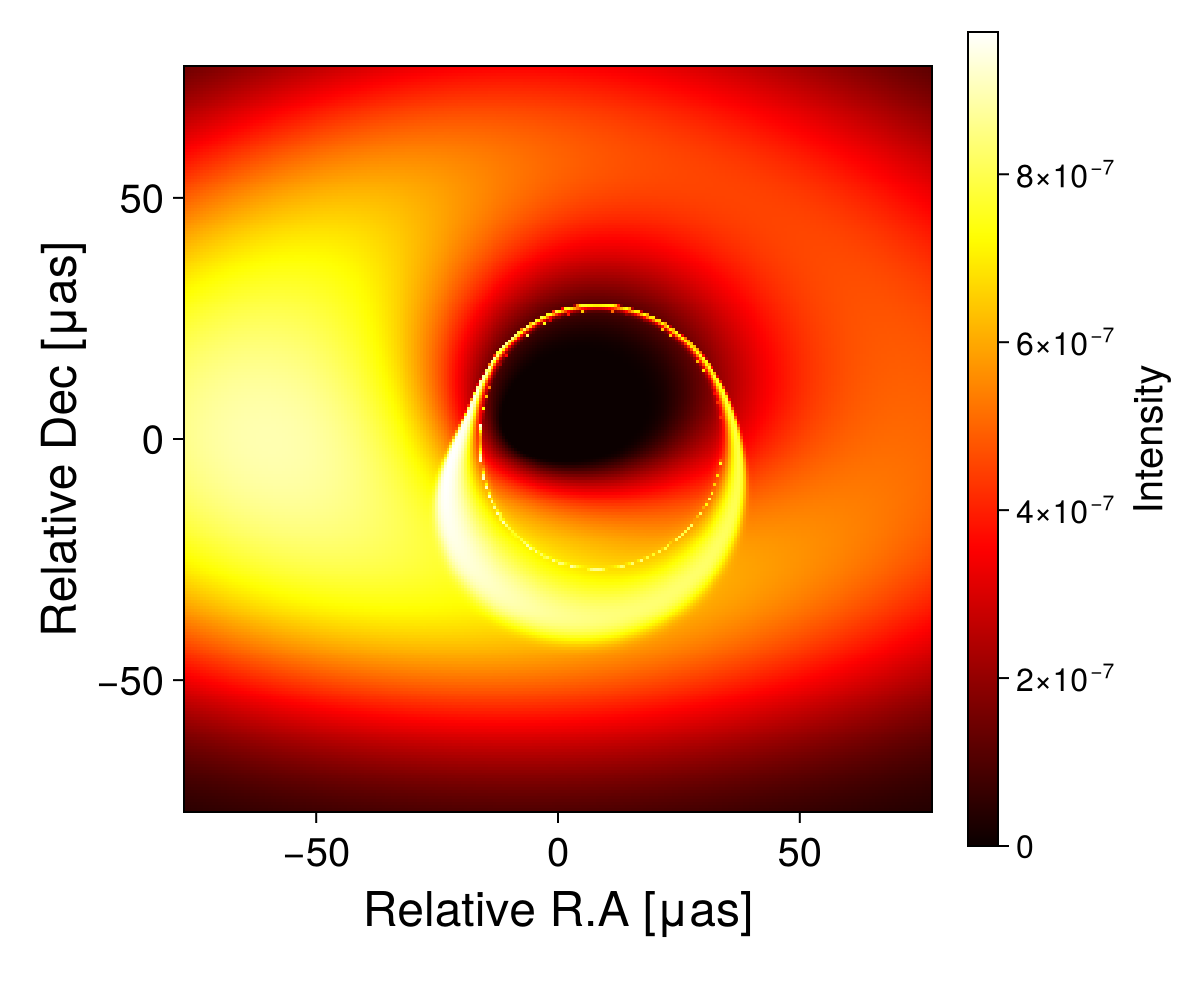

In [5]:
using CairoMakie

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           
fov_rg = 30
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm   
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig

# Thin Disk Model

In [1]:
using Jipole
using StaticArrays

[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413](cache misses: include_dependency fsize change (1))
[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Chandra table loaded successfully from /home/mottapn/current/Jipole/src/models/../../Tables/ch24_vals.txt


In [2]:
#THIN DISK PARAMETERS
#Setting up the parameters
#Observer distance in Rg
const ro = 10000.0
#Observer inclination in degrees
const th = 75.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 40.0
const DYsize = 40.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 256
const pixels_x = 256
const pixels_y = 256

# Distance to the source in parsecs
const SourceD = 0.05 * Jipole.Constants.PC
const Rout = 1000.0
const Rstop = 10000.0

# Frequency observed by the camera in Hz
const freq = 2.417989e17#230e9
const bhspin = 0.99
const Rh = 1 + sqrt(1. - bhspin * bhspin);
const cstartx = MVector{4,Float64}(0.0, log(Rh), 0.0, 0.0)
const cstopx = MVector{4,Float64}(0.0, log(1000.0), 1.0, 2.0 * π);

# Black hole mass, in solar masses, and mass accretion rate, in g/s
const MBH = 10.0
const Mdotedd = 4 * π * Jipole.Constants.GNEWT * MBH * Jipole.Constants.MSUN * Jipole.Constants.MP/(0.1)/Jipole.Constants.CL/Jipole.Constants.SIGMA_THOMPSON
const Mdot = 0.01 * Mdotedd 

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0;
const maxnstep = 25000;

In [3]:
model = Jipole.ThinDisk.ThinDiskParams(bhspin, Rout, cstartx, cstopx, MBH, Mdot, Rstop)

Jipole.ThinDisk.ThinDiskParams(0.99, 1000.0, [0.0, 0.13196410489257573, 0.0, 0.0], [0.0, 6.907755278982137, 1.0, 6.283185307179586], 0, 1.0, 1.8, 1.4544979380596716, 1.8663395295703202e7, 1.4770411469180877e6, 4.926878937421727e-5, 10000.0)

In [4]:
Image = Jipole.Imaging.raytrace_image(model, nothing, ro, th, phi, freq, pixels_x, pixels_y, fovx, fovy, maxnstep, Rh, xoff, yoff);

Allocating workspaces for 256 row-tasks...
Tracing Geodesics...


Raytracing Image... 100%|██████████████████████████████| Time: 0:00:01 (28.10 μs/it)


In [5]:
const scale_factor = Jipole.Imaging.calculate_scale_factor(DXsize, DYsize, pixels_x, pixels_y, SourceD, model.L_unit)
Jipole.Imaging.output_stokes_parameters(Image, freq, scale_factor, pixels_x, pixels_y, SourceD) 

Image processing complete. Calculating total flux and averages...
Scale = 0.2237608086843551
imax = 109, jmax = 135, Imax = 19011.287327505746, Iavg = 467.828705231991
Total Flux Fnu = 6.860421818513054e6 Jy
nuLnu = 4.9619938451344925e36


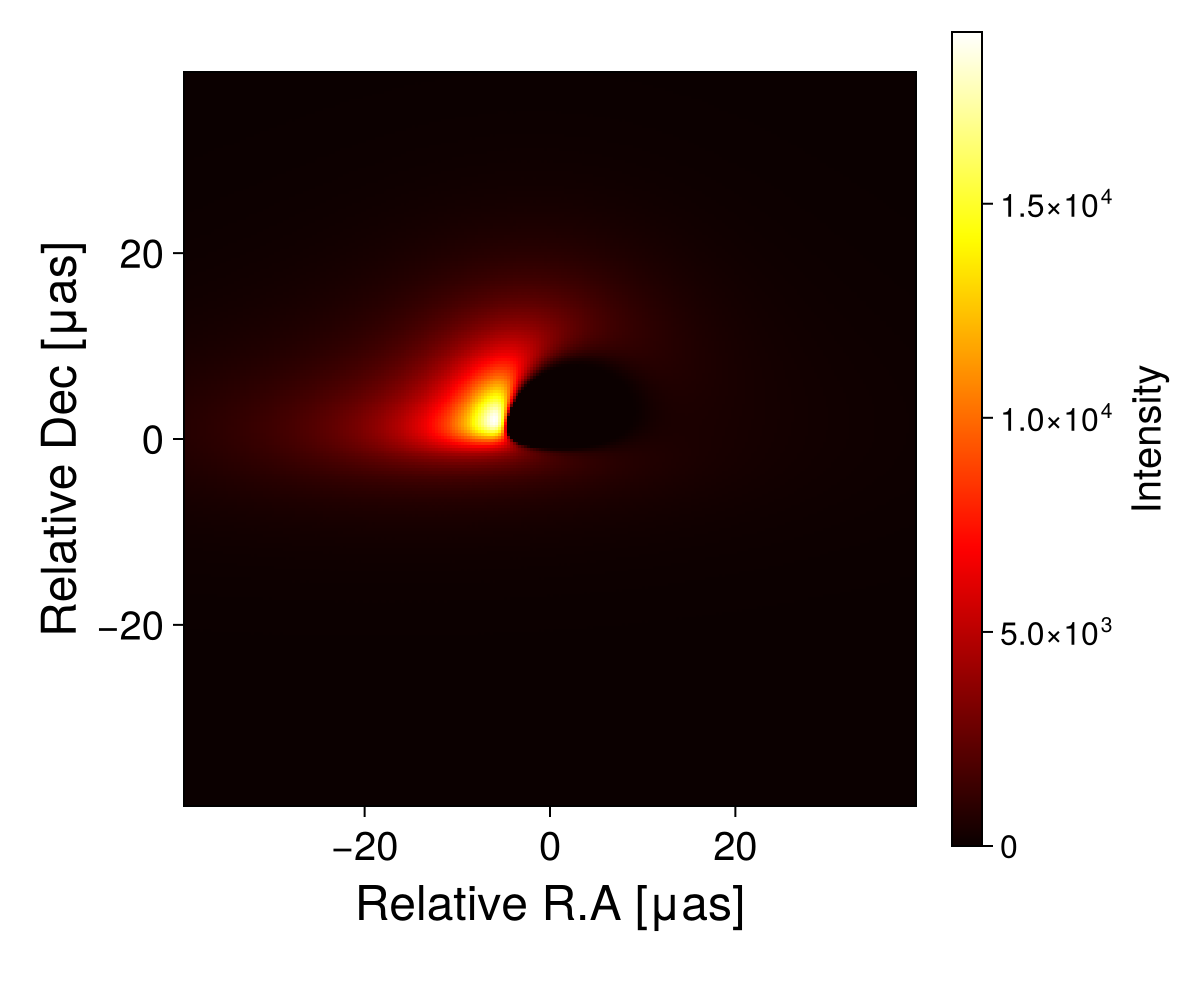

In [6]:
using CairoMakie
using Printf


d_kpc = 0.05 * 1/1000
d_cm = d_kpc * 3.086e21           
fov_rg = 40
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm   
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig